<a href="https://colab.research.google.com/github/Aapocalypsez/aapocalypsez/blob/main/For_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance

# keras
from tensorflow.keras.preprocessing.image import load_img #for loading images
from tensorflow.keras.models import Sequential # for building the model
from tensorflow.keras.layers import Input, Flatten, Dropout,  Dense # for model layers
from tensorflow.keras.optimizers import Adam  #for optimizer
from tensorflow.keras.applications import VGG16 #for using VGG16 model
from sklearn.utils import shuffle #for shuffling the data
import cv2
from collections import Counter
from sklearn.preprocessing import LabelEncoder



In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
train_dir = '/content/drive/MyDrive/MRI DataSet/Training/'
test_dir = '/content/drive/MyDrive/MRI DataSet/Testing/'

#load train data and shuffle
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir , label)):
    train_paths.append(os.path.join(train_dir , label ,image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

#load test and shuffle

test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir , label)):
    test_paths.append(os.path.join(test_dir , label ,image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

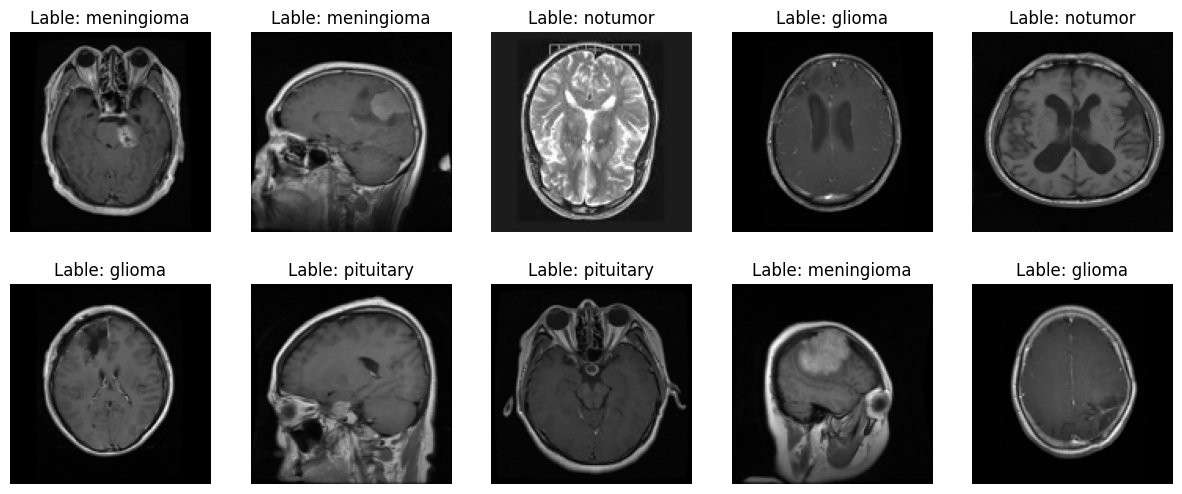

In [16]:
import random
import matplotlib.pyplot as plt

#select random indcies for 10 images

random_indices = random.sample(range(len(train_paths)), 10)

#create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize = (15, 6))
axes = axes.ravel()

#loop through the random indices and display images
for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128, 128))

  #display image
  axes[i].imshow(img, cmap= 'gray')
  axes[i].set_title(f"Lable: {train_labels[idx]}")
  axes[i].axis('off')






**Image Preprocessing**

In [17]:
#image Augmentation Function
def augment_image(image):
    image = Image.fromarray(np.uint8(image * 255))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image)/255.0
    return image



#load images and apply augmentation
def open_image(paths):
    images = []
    for path in paths:
      img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
      img = np.array(img)
      img = augment_image(image)
      images.append(image)
    return np.array(images)#CNN


#Encoder labels (name to int)
def encode_label(labels):
  unique_labels = os.listdir(train_dir)
  encode = [unique_labels.index(label) for label in lables]
  return np.array(encode)

#Data generator for batching (read data in batches)
def datagen(paths, labels, batch_size):
    while True:
        for i in range(0, len(paths), batch_size):

            batch_paths = paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]


            images = []

            for path in batch_paths:
                img = load_img(path, target_size=(128,128))
                img = np.array(img)
                img = img / 255.0
                img = augment_image(img)
                images.append(img)


            X = np.array(images, dtype=np.float32)
            y = np.array(batch_labels, dtype=np.int32)

            yield X, y

In [18]:
print("Train images:", len(train_paths))
print("Test images:", len(test_paths))
print("Total images:", len(train_paths) + len(test_paths))

Train images: 5600
Test images: 1600
Total images: 7200


# **MODEL**

In [14]:
from IPython.core import history
from scipy import sparse
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D
print(tf.config.list_physical_devices())

AUTOTUNE    = tf.data.AUTOTUNE
batch_size = 20
IMAGE_SIZE = 128

le = LabelEncoder()
train_labels_enc = le.fit_transform(train_labels)  # converts ['notumor', 'tumor', ...] → [0, 1, ...]
test_labels_enc = le.transform(test_labels)
print(dict(zip(le.classes_, le.transform(le.classes_))))


# ── tf.data Pipeline ──────────────────────────────────────────────────────────
def parse_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_flip_left_right(img)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(paths, labels, batch_size, augment_data=True, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((
        tf.constant(paths),
        tf.constant(labels, dtype=tf.int32)
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths))
    dataset = dataset.map(parse_image, num_parallel_calls=AUTOTUNE)
    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=AUTOTUNE)
    return dataset.batch(batch_size).prefetch(AUTOTUNE)

train_dataset = make_dataset(train_paths, train_labels_enc, batch_size, augment_data=True)
val_dataset   = make_dataset(test_paths,  test_labels_enc,  batch_size, augment_data=False, shuffle=False)


# ── Fix callbacks with correct metric names ──────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',        # ✅ fixed metric name
        patience=3,
        restore_best_weights=True,
        mode='min'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',        # ✅ fixed metric name
        save_best_only=True,
        mode='min'
    )
]

# Optional: see the mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))

#Model Architecture

base_model = VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE, 3), include_top=False, weights='imagenet')

#freeze all layers of the VGG16 base model
for layer in base_model.layers:
  layer.trainable = False

#set only the last few layers

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = False
#build model

model = Sequential() #help in making neural networks
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE, 3))) #input layers
model.add(base_model) #VGG16 model
model.add( GlobalAveragePooling2D())

model.add(Dropout(0.5))
model.add(Dense(256, activation='relu')) #dense layer
 #dense layer
##this part in convolutional neural netwrok

model.add(Dropout(0.3))
model.add(Dense( len(le.classes_), activation='softmax')) #output layer
#use softmax for multiclass classificatoin

#compiler the model
model.compile(optimizer=Adam(learning_rate=0.00001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

#Parametars
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 30

history = model.fit(
    datagen(train_paths, train_labels_enc, batch_size),
    steps_per_epoch=len(train_paths)//batch_size,
    epochs = epochs,
    validation_data=datagen(test_paths, test_labels_enc, batch_size),  # ✅ added
    validation_steps=len(test_paths) // batch_size,                # ✅ added
    callbacks=callbacks

)


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
{np.str_('glioma'): np.int64(0), np.str_('meningioma'): np.int64(1), np.str_('notumor'): np.int64(2), np.str_('pituitary'): np.int64(3)}
{np.str_('glioma'): np.int64(0), np.str_('meningioma'): np.int64(1), np.str_('notumor'): np.int64(2), np.str_('pituitary'): np.int64(3)}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 4,851,972 (18.51 MB)

 Non-trainable params: 9,995,072 (38.13 MB)

Epoch 1/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.3695 - loss: 1.3612 - val_accuracy: 0.7156 - val_loss: 0.8109 - learning_rate: 1.0000e-05
Epoch 2/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 154ms/step - accuracy: 0.7102 - loss: 0.7600 - val_accuracy: 0.7688 - val_loss: 0.6955 - learning_rate: 1.0000e-05
Epoch 3/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 45s 162ms/step - accuracy: 0.8028 - loss: 0.5552 - val_accuracy: 0.7850 - val_loss: 0.6583 - learning_rate: 1.0000e-05
Epoch 4/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 154ms/step - accuracy: 0.8266 - loss: 0.4734 - val_accuracy: 0.8000 - val_loss: 0.6229 - learning_rate: 1.0000e-05
Epoch 5/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 151ms/step - accuracy: 0.8464 - loss: 0.4229 - val_accuracy: 0.8069 - val_loss: 0.6013 - learning_rate: 1.0000e-05
Epoch 6/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 155ms/step - accuracy: 0.8602 - loss: 0.3753 - val_accuracy: 0.8219 - val_loss: 0.5693 - learning_rate: 1.0000e-05
Epoch 7/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 15

# **Train and  Val Plots**

NameError: name 'history' is not defined

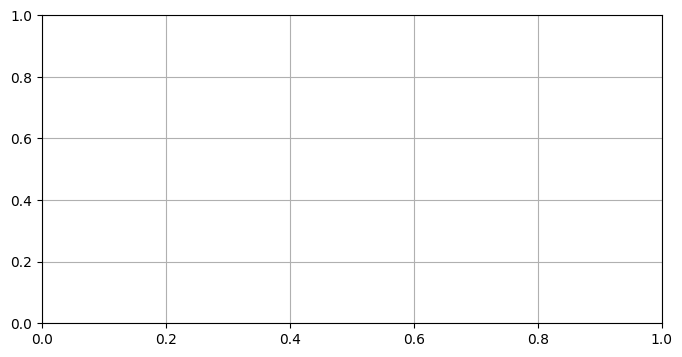

In [7]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['accuracy'], '.g-' , linewidth=2)
plt.plot(history.history['loss'], '.r-' , linewidth=2)
plt.title('Model Training history')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()

## **Model Classification Report**

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions (using val_dataset that's already loaded)
y_pred = model.predict(val_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in val_dataset], axis=0)

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))




80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.70      0.80       400
  meningioma       0.78      0.89      0.83       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.95      0.95      0.95       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



# **Confusion Plot**

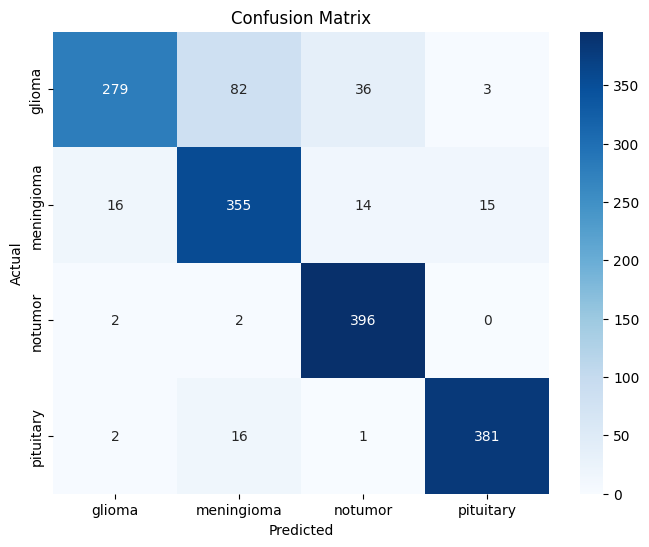

In [21]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **ROC Curve**

80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step


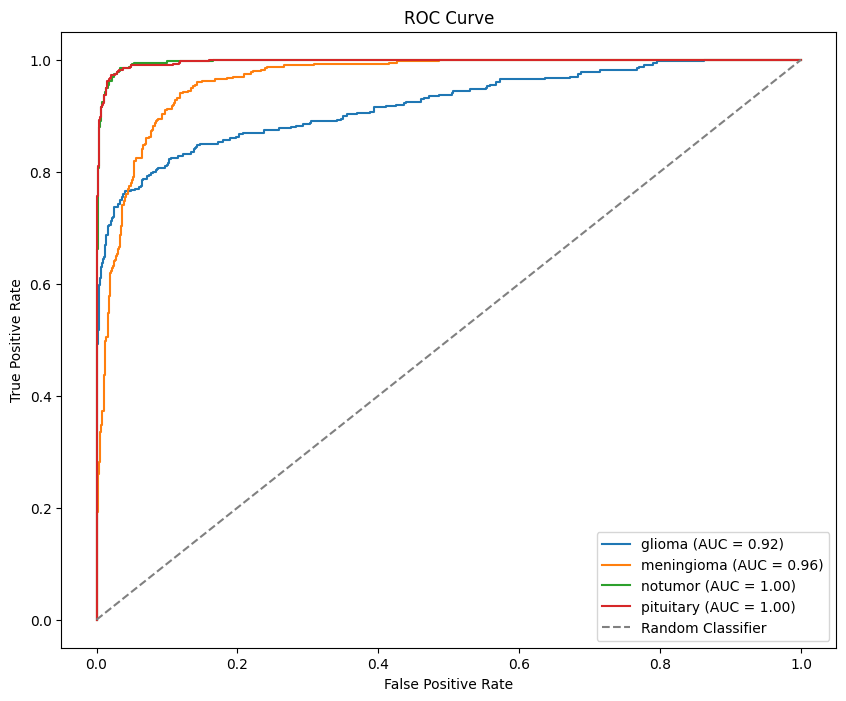

In [26]:
#RIC  Curve and AUC
#Binarize the test labels and pridictions for multi-class Roc
# ROC Curve and AUC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and true labels from val_dataset
y_pred = model.predict(val_dataset)
y_true = np.concatenate([y for x, y in val_dataset], axis=0)

# Binarize
n_classes = len(le.classes_)
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# Compute ROC curve for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()



In [8]:
#Save the entire model
model.save('MRI_model.h5')

NameError: name 'model' is not defined

In [12]:
from google.colab import files
uploaded = files.upload()  # select your MRI_model.h5 file

Saving MRI_model.h5 to MRI_model.h5


In [19]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

model = load_model('MRI_model.h5')
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model loaded successfully!")

Model loaded successfully!


In [20]:
from tensorflow.keras.models import load_model
#load the trained model
model = load_model('MRI_model.h5')

# ***MRI Tumor Detection System***

In [45]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# ✅ Use le.classes_ instead of manual list
# ✅ Manually define in correct alphabetical order
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Class labels order:", class_labels)
  # verify

def detect_and_display(image_path, model):
    try:
        img = load_img(image_path, target_size=(128, 128))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.0

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions)
        confidence_score = np.max(predictions, axis=1)[0]

        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor Detected"
        else:
            result = f"Tumor Detected: {class_labels[predicted_class_index]}"

        plt.imshow(load_img(image_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


Class labels order: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [47]:
import os
# Check exact folder names in Testing
print(os.listdir('/content/drive/MyDrive/MRI DataSet/Testing/'))

['pituitary', 'glioma', 'notumor', 'meningioma']


Testing: Training - Meningioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


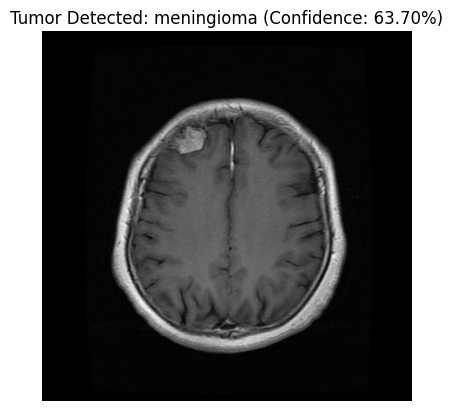

Testing: Training - Pituitary
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


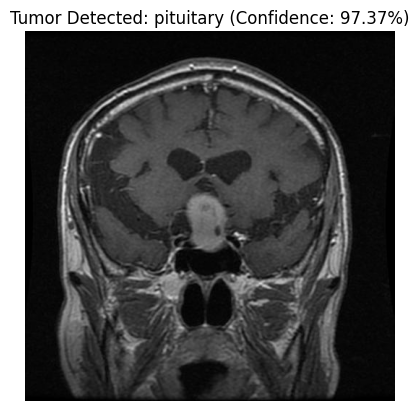

Testing: Training - Glioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


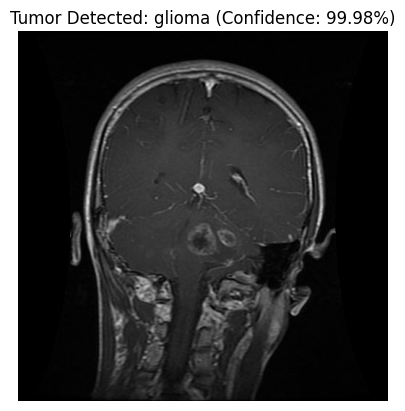

Testing: Training - Notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


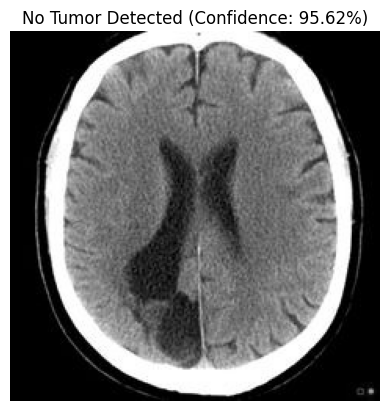

Testing: Testing - Meningioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


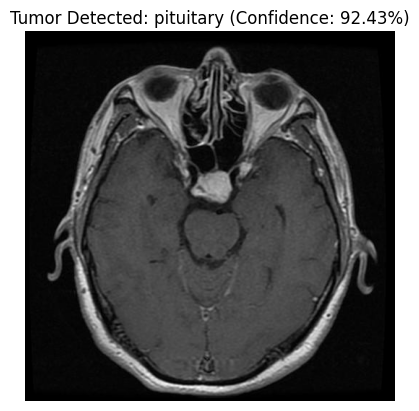

Testing: Testing - Glioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step


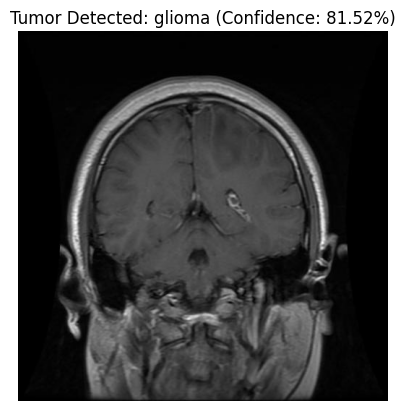

Testing: Testing - Notumor
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


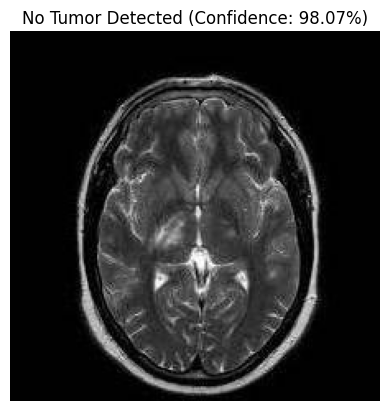

Testing: Testing - Pituitary
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step


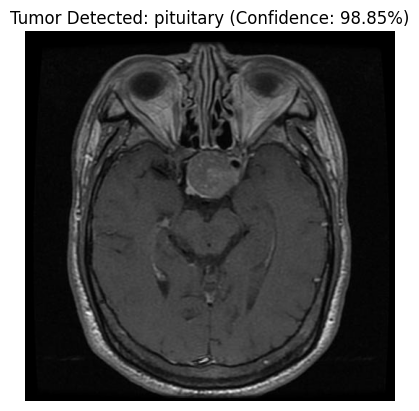

In [48]:
#calling function
#Example usage

# Training images
image_path = '/content/drive/MyDrive/MRI DataSet/Training/meningioma/Tr-me_95.jpg'
print("Testing: Training - Meningioma")
detect_and_display(image_path, model)

image_path = '/content/drive/MyDrive/MRI DataSet/Training/pituitary/Tr-pi_789.jpg'
print("Testing: Training - Pituitary")
detect_and_display(image_path, model)

image_path = '/content/drive/MyDrive/MRI DataSet/Training/glioma/Tr-gl_963.jpg'
print("Testing: Training - Glioma")
detect_and_display(image_path, model)

image_path = '/content/drive/MyDrive/MRI DataSet/Training/notumor/Tr-no_911.jpg'
print("Testing: Training - Notumor")
detect_and_display(image_path, model)

# Testing images
image_path = '/content/drive/MyDrive/MRI DataSet/Testing/meningioma/Te-me_169.jpg'
print("Testing: Testing - Meningioma")
detect_and_display(image_path, model)

image_path = '/content/drive/MyDrive/MRI DataSet/Testing/glioma/Te-gl_336.jpg'
print("Testing: Testing - Glioma")
detect_and_display(image_path, model)

image_path = '/content/drive/MyDrive/MRI DataSet/Testing/notumor/Te-no_314.jpg'
print("Testing: Testing - Notumor")
detect_and_display(image_path, model)

image_path = '/content/drive/MyDrive/MRI DataSet/Testing/pituitary/Te-pi_43.jpg'
print("Testing: Testing - Pituitary")
detect_and_display(image_path, model)